## Predicting the sale price of Bulldoxers using machine learning
-In this notebook. we're going to go through an example machine learning project with the goal of predicting the price of dulldozers


## 1.Problem defintion
     -how well can we predict the future sale price of a bulldozer,given its characterstics and previous example of how much similar bulldozers have been sold for?

## 2.Data
  -the data is downloaded from the kaggle bluebook for bulldozer competition:
https://www.kaggle.com/c/bluebook-for-bulldozers
-There are 3 main datasets:
* Train.csv is the training set, which contains data through the end of 2011.
* Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.
* Test.csv is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.

## 3. Evalution
The evaluation metric for this competition is the RMSLE(root mean squared log error) between the actual and predicted auction prices.

**note**: the goal for most regression evaluation metrics is to minimize the error. for example, our goal for this project will be to build a machine learning model that minimizes RMSLE




## Features
kaggel provides a data dictionary detailing all of the features of the dataset.you can seeit in the following link:
https://eu.docworkspace.com/d/sIK_3oeLUAp3F88oG?sa=601.1037


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn



In [14]:
# imprt the training and validation set
df=pd.read_csv("Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\TrainAndValid.csv",low_memory=False)

<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
C:\Users\raeey\AppData\Local\Temp\ipykernel_9228\448015856.py:2: SyntaxWarning: invalid escape sequence '\B'
  df=pd.read_csv("Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\TrainAndValid.csv",low_memory=False)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [16]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

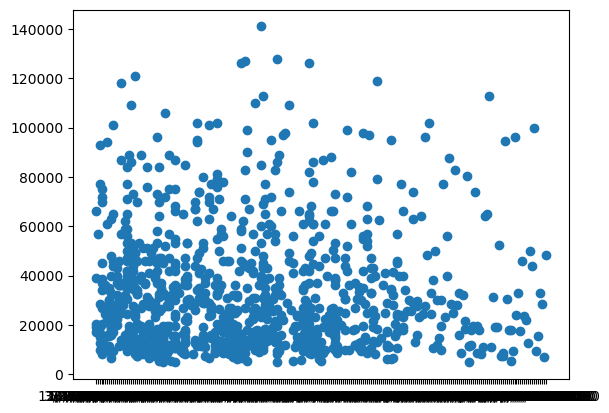

In [17]:
fig,ax= plt.subplots()
ax.scatter(df["saledate"][:1000],df["SalePrice"][:1000])

In [18]:
df["saledate"]

0         11/16/2006 0:00
1          3/26/2004 0:00
2          2/26/2004 0:00
3          5/19/2011 0:00
4          7/23/2009 0:00
               ...       
412693      3/7/2012 0:00
412694     1/28/2012 0:00
412695     1/28/2012 0:00
412696      3/7/2012 0:00
412697     1/28/2012 0:00
Name: saledate, Length: 412698, dtype: object

<Axes: ylabel='Frequency'>

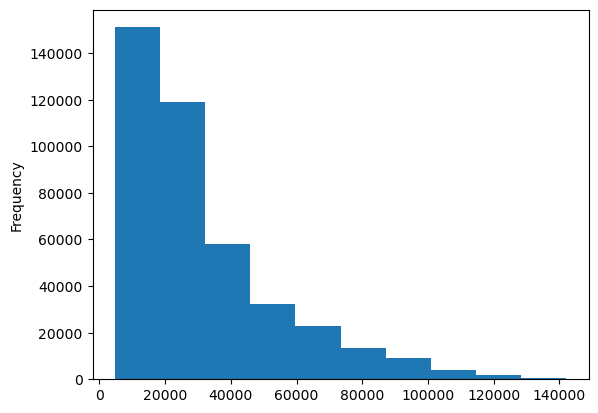

In [19]:
df.SalePrice.plot.hist()

## parsing dates

when we work with time series data, we want to enrich the rime & component as much as possible. 

we can do that by telling pandas which of pur columns has dates in it using the "parsedate" parameter

In pandas, a DateTime object refers to a special data type used to represent dates and times with nanosecond precision.

The most common form is the pandas.Timestamp object, which is essentially pandas’ enhanced version of Python’s built-in datetime.datetime. It is based on NumPy’s datetime64 type, making it faster and more precise than Python’s standard datetime.

In [20]:
# import data again, but this parse dates
df=pd.read_csv("Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\TrainAndValid.csv", low_memory=False,parse_dates=["saledate"]) 


<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
C:\Users\raeey\AppData\Local\Temp\ipykernel_9228\3158057767.py:2: SyntaxWarning: invalid escape sequence '\B'
  df=pd.read_csv("Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\TrainAndValid.csv", low_memory=False,parse_dates=["saledate"])


In [21]:
df.saledate.dtype

dtype('<M8[ns]')

In [22]:
df.saledate[:1000]

0     2006-11-16
1     2004-03-26
2     2004-02-26
3     2011-05-19
4     2009-07-23
         ...    
995   2009-07-16
996   2007-06-14
997   2005-09-22
998   2005-07-28
999   2011-06-16
Name: saledate, Length: 1000, dtype: datetime64[ns]

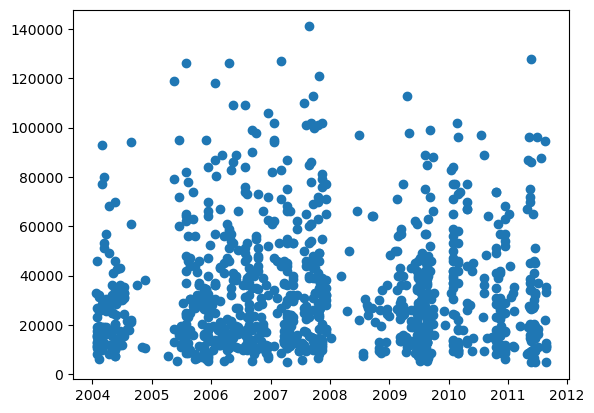

In [23]:
fig,ax= plt.subplots()
ax.scatter(df["saledate"][:1000],df["SalePrice"][:1000])

<Axes: ylabel='Frequency'>

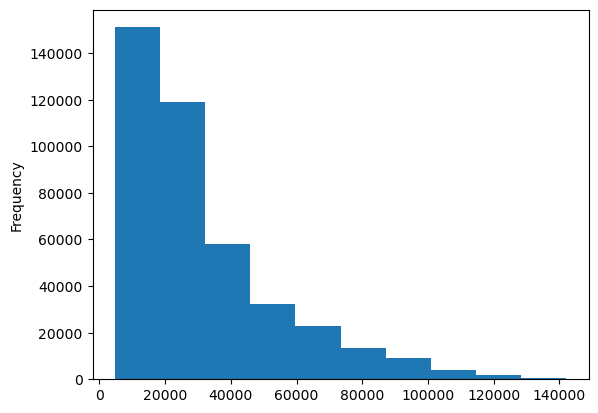

In [24]:
df.SalePrice.plot.hist()

In [25]:
df.head()


,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df.saledate.head(20)

0    2006-11-16
1    2004-03-26
2    2004-02-26
3    2011-05-19
4    2009-07-23
5    2008-12-18
6    2004-08-26
7    2005-11-17
8    2009-08-27
9    2007-08-09
10   2008-08-21
11   2006-08-24
12   2005-10-20
13   2006-01-26
14   2006-01-03
15   2006-11-16
16   2007-06-14
17   2010-01-28
18   2006-03-09
19   2005-11-17
Name: saledate, dtype: datetime64[ns]

### sort DataFrame by saledate

when working with tie series data, it's a good idea to sort it by data

In [27]:
# sort DataFrame in data order
df.sort_values(by=["saledate"],inplace=True,ascending=True)
df.saledate.head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[ns]

## Make a copy of the orginal dataframe
we make copy of teh eorginal data so we can reverrt to it.

In [28]:
df_tmp=df.copy()

In [29]:
df_tmp

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
205615,1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
274835,1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
141296,1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
212552,1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
62755,1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,Lever,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
410879,6302984,16000.0,1915521,5266,149,99.0,2001,NaN,NaN,2012-04-28,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN
412476,6324811,6000.0,1919104,19330,149,99.0,2004,NaN,NaN,2012-04-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
411927,6313029,16000.0,1918416,17244,149,99.0,2004,NaN,NaN,2012-04-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
407124,6266251,55000.0,509560,3357,149,99.0,1993,NaN,NaN,2012-04-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 ## Feature enginnering- tweaking the existing data to create new features

##  add datatime parameter for saledate column

In [30]:
df_tmp["saleYear"]=df_tmp.saledate.dt.year
df_tmp["saleMonth"]=df_tmp.saledate.dt.month
df_tmp["saleDay"]=df_tmp.saledate.dt.day

In [31]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [32]:
# now we've enriched our df now with date tiem features we can remove the saledate
df_tmp.drop("saledate",axis=1,inplace=True)

In [33]:
df_tmp[:1000].saledate.dt.year

AttributeError: 'DataFrame' object has no attribute 'saledate'

In [ ]:
#check the values of differnent columns
df_tmp.state.value_counts()

## 5.Modelling

we've done enough EDA(we could alwys do more) but let's start to do some model-driven EDA()

In [ ]:
#lets build a machine learning model


from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_jobs=-1,
                            random_state=42)

model.fit(df_tmp.drop("SalePrice",axis=1),df_tmp["SalePrice"])

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   object        
 9   saledate                  412698 non-null  datetime64[ns]
 10  fiModelDesc               412698 non-null  object        
 11  fiBaseModel               412698 non-null  object        
 12  fi

In [35]:
df_tmp["UsageBand"].dtype

dtype('O')

In [36]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

### covert stright to catargories

one way we can turn all our data into numbers is by converting it into pandas categories

We can check differnet dtpes conpatble with pandas " https://pandas.pydata.org/pandas-docs/version/1.4/reference/general_utility_functions.html "

In [73]:
pd.api.types.is_string_dtype(df_tmp["UsageBand"])

False

In [37]:
 # find the columns which contian strings
for label,content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        print(label)
        
    
    

fiModelDesc
fiBaseModel
fiProductClassDesc
state
ProductGroup
ProductGroupDesc


In [38]:
# if you're wondering what df_tmp.item() does ,her eis the example
random_dict={"key1":"hellow"
             ,"key2":"helloww",
             "key3":"hellowww"
            }
for key,value in random_dict.items():
    print(f'this is a key {key}',
         f"this is a value {value}")

this is a key key1 this is a value hellow
this is a key key2 this is a value helloww
this is a key key3 this is a value hellowww


In [39]:
# this woll turn all the string value into catagory values
for label, content in df_tmp.items():
    if pd.api.types.is_object_dtype(content):
        df_tmp[label]=content.astype("category").cat.as_ordered()

In [40]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [78]:
df_tmp.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [79]:
df_tmp.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Montana            1336
Iowa               1336
Oklahoma           1326
Nebraska            866
West Virgi

In [80]:
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

thanks to pandas categories we now hav a way to acess all of our data in the form of numbers

but we still have a bunch of missing data

In [81]:
# check missing data
df_tmp.isnull().sum()/len(df_tmp)

SalesID                     0.000000
SalePrice                   0.000000
MachineID                   0.000000
ModelID                     0.000000
datasource                  0.000000
auctioneerID                0.048791
YearMade                    0.000000
MachineHoursCurrentMeter    0.642586
UsageBand                   0.821492
fiModelDesc                 0.000000
fiBaseModel                 0.000000
fiSecondaryDesc             0.340993
fiModelSeries               0.857845
fiModelDescriptor           0.818715
ProductSize                 0.524851
fiProductClassDesc          0.000000
state                       0.000000
ProductGroup                0.000000
ProductGroupDesc            0.000000
Drive_System                0.740520
Enclosure                   0.000809
Forks                       0.520921
Pad_Type                    0.803498
Ride_Control                0.629928
Stick                       0.803498
Transmission                0.544444
Turbocharged                0.803498
B

### save preproccessed data

In [41]:
df_tmp.to_csv(
    r"C:\Users\raeey\Desktop\sample_project_1\real_project_1\Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\df_tmp.csv",
    index=False
)


In [42]:
#import preproccesed data
df_tmp=pd.read_csv(
    r"C:\Users\raeey\Desktop\sample_project_1\real_project_1\Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\df_tmp.csv",
    
)


C:\Users\raeey\AppData\Local\Temp\ipykernel_9228\3314760188.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp=pd.read_csv(


## fill missing values
### fill numeric missing values

In [43]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay


In [44]:
df_tmp.ModelID

0          8434
1         10150
2          4139
3          8591
4          4089
          ...  
412693     5266
412694    19330
412695    17244
412696     3357
412697     4701
Name: ModelID, Length: 412698, dtype: int64

In [45]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


In [46]:
## fill numberic rows with the median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # add a binary column which tells us if the data was missing
            df_tmp[label+"_is_missing"]=pd.isnull(content)
            ## fill numberic rows with the median (more robust than mean for this case)
            df_tmp[label]=content.fillna(content.median())
            
        

In [47]:
# demonstrate how meadian is more robust than mean
## Mean is sensitive to extreme values.
## Median is resistant (robust) to extreme values.
hun=np.full((1000,),100)
hun_bill=np.append(hun,1000000)
np.mean(hun),np.mean(hun_bill),np.median(hun),np.median(hun_bill)
    

(np.float64(100.0),
 np.float64(1098.901098901099),
 np.float64(100.0),
 np.float64(100.0))

In [48]:
# CHECK if there's anu null numberic vale
for label, content in df_tmp.items():
    if   pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum(): 
            print(label)

In [49]:
#check to see how many examples were missing
df_tmp["auctioneerID"].isna().sum()


np.int64(0)

In [50]:
df_tmp.isna().sum()


SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

## Filling and tuninrg catergorical Varibale into number


In [51]:
# checkfor column which are nor numberic
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)
    

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [52]:
df_tmp.isna().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

In [53]:
# Turn categorical varibales ito numbers and fill missing
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        #add binary column to indicte whether sample has missing value
        df_tmp[label+"_is_missing"]=pd.isnull(content)
        # Turn categories into numbers and add +1
        df_tmp[label]=pd.Categorical(content).codes + 1

In [54]:
## so the catergories might look the same as 
##the string but inthe background is an asigned  unique code


pd.Categorical(df_tmp['state']).codes+1

array([44,  9,  9, ...,  5,  5,  5], shape=(412698,), dtype=int8)

In [55]:
## NaN = -1
##  🔹 Why is -1 a problem?

# Many machine learning models:
# 
# Don’t expect negative category codes
# 
# Might interpret -1 as a real numeric value
# 
# Could treat it as “less than everything else”
# 
# That’s dangerous.

In [56]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Columns: 101 entries, SalesID to Steering_Controls_is_missing
dtypes: bool(46), float64(3), int16(4), int64(8), int8(40)
memory usage: 71.6 MB


In [57]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting_is_missing,False,True,False,True,False
Blade_Type_is_missing,False,True,False,True,False
Travel_Controls_is_missing,False,True,False,True,False
Differential_Type_is_missing,True,False,True,False,True


In [58]:
df_tmp.isna().sum()[:30]

SalesID                     0
SalePrice                   0
MachineID                   0
ModelID                     0
datasource                  0
auctioneerID                0
YearMade                    0
MachineHoursCurrentMeter    0
UsageBand                   0
fiModelDesc                 0
fiBaseModel                 0
fiSecondaryDesc             0
fiModelSeries               0
fiModelDescriptor           0
ProductSize                 0
fiProductClassDesc          0
state                       0
ProductGroup                0
ProductGroupDesc            0
Drive_System                0
Enclosure                   0
Forks                       0
Pad_Type                    0
Ride_Control                0
Stick                       0
Transmission                0
Turbocharged                0
Blade_Extension             0
Blade_Width                 0
Enclosure_Type              0
dtype: int64

## 
now that all th data is numberic aswellas our dataframe has no missing values,
we should be able to build a machine learning model

In [59]:
len(df_tmp)

412698

In [60]:
df_tmp

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,9500.0,1126363,8434,132,18.0,1974,0.0,0,4593,...,True,True,True,True,True,False,False,False,True,True
1,1821514,14000.0,1194089,10150,132,99.0,1980,0.0,0,1820,...,True,True,True,True,True,True,True,True,False,False
2,1505138,50000.0,1473654,4139,132,99.0,1978,0.0,0,2348,...,True,True,True,True,True,False,False,False,True,True
3,1671174,16000.0,1327630,8591,132,99.0,1980,0.0,0,1819,...,True,True,True,True,True,True,True,True,False,False
4,1329056,22000.0,1336053,4089,132,99.0,1984,0.0,0,2119,...,True,True,True,True,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6302984,16000.0,1915521,5266,149,99.0,2001,0.0,0,2101,...,True,True,True,True,True,False,False,False,True,True
412694,6324811,6000.0,1919104,19330,149,99.0,2004,0.0,0,240,...,True,True,True,True,True,True,True,True,True,True
412695,6313029,16000.0,1918416,17244,149,99.0,2004,0.0,0,627,...,True,True,True,True,True,True,True,True,True,True
412696,6266251,55000.0,509560,3357,149,99.0,1993,0.0,0,83,...,True,True,True,True,True,True,True,True,True,True


In [61]:
%%time
# instantiate model 
model=RandomForestRegressor(n_jobs=-1,random_state=42)

#fit hte model
model.fit(df_tmp.drop("SalePrice",axis=1),df_tmp["SalePrice"])


CPU times: total: 38min 24s
Wall time: 6min 21s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
#score the model
model.score(df_tmp.drop("SalePrice",axis=1),df_tmp["SalePrice"])

0.9875132974990518

## *Question* whu doesn't the above metric hold water?(why isnt the metric reliable)
answer-- cant score on same dataset we used for traning

### spliting data into train/validatin set

In [63]:
df_tmp.saleYear

0         1989
1         1989
2         1989
3         1989
4         1989
          ... 
412693    2012
412694    2012
412695    2012
412696    2012
412697    2012
Name: saleYear, Length: 412698, dtype: int64

In [64]:
df_tmp.saleYear.value_counts()

saleYear
2009    43849
2008    39767
2011    35197
2010    33390
2007    32208
2006    21685
2005    20463
2004    19879
2001    17594
2000    17415
2002    17246
2003    15254
1998    13046
1999    12793
2012    11573
1997     9785
1996     8829
1995     8530
1994     7929
1993     6303
1992     5519
1991     5109
1989     4806
1990     4529
Name: count, dtype: int64

In [66]:
# split data into traing and validation
df_val=df_tmp[df_tmp.saleYear==2012]
df_train=df_tmp[df_tmp.saleYear!=2012]

len(df_val),len(df_train)

(11573, 401125)

In [187]:
# split the data into x & y
x_train,y_train=df_train.drop("SalePrice",axis=1),df_train.SalePrice
x_valid,y_valid=df_val.drop("SalePrice",axis=1),df_val.SalePrice

x_train.shape,y_train.shape,x_valid.shape,y_valid.shape

((401125, 100), (401125,), (11573, 100), (11573,))

 ## Building an Evaluation function
 

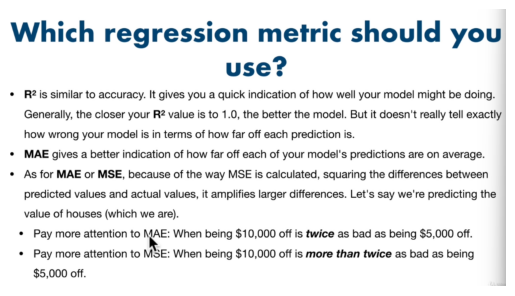

In [68]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Full path to image (change username and filename)
img_path = r"C:\Users\raeey\Desktop\Screenshot 2026-02-18 104946.png"

img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis("off")  # hides axes
plt.show()


In [80]:
#create evaluation function(the competition uses RMSLE)
## mean_squared_log error= more of a ration(10%)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error,r2_score
 
def rmsle(y_test,y_preds):
    """ 
    calculates root mean squared log error between predictions and true labels
    """
    return np.sqrt(mean_squared_log_error(y_test,y_preds))
# create a function to evaluate model on a few differnt levels
def show_scores(model):
    train_preds=model.predict(x_train)
    val_preds=model.predict(x_valid)
    scores={"Training MAE":mean_absolute_error(y_valid, val_preds),
           "valid MAE":mean_absolute_error(y_valid, val_preds),
           "Training RMSLE":rmsle(y_train,train_preds),
           "Valid RMSLE":rmsle(y_valid,val_preds),
           "Training R^2":r2_score(y_valid,val_preds)}
    return scores

## Testing our models on a subset(to tune the hyperparameter)

In [70]:
#%%time
#model=RandomForestReressor(n_jobs+-1,
#                          random_state=42)
#model.fit(x_train,y_train)

In [71]:
len(x_train)

401125

In [72]:
# option 1
# model.fit(x_train[:1000],y_train[:1000])


#change max_sample value
model=RandomForestRegressor(n_jobs=-1,
                          random_state=42,
                           max_samples=10000)
model

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
%%time
## cutting down the max number of samples each estimator can see imported
model.fit(x_train,y_train)

CPU times: total: 1min 18s
Wall time: 13.7 s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
x_train.shape[0]

401125

In [75]:
show_scores(model)

{'Training MAE': 7090.7533897865715,
 'valid MAE': 7090.7533897865715,
 'Training RMSLE': np.float64(0.25647273079766847),
 'Valid RMSLE': np.float64(0.2895513455735602),
 'Training R^2': 0.8346268881678072}

### Hyperparamter tuning with RnadmizedSearchCV

In [103]:
%%time

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# different RanfomForestRegessor hyperparameters
rf_grid = {
    "n_estimators": np.arange(10, 100, 10),
    "max_depth": [None, 3, 5, 10],
    "min_samples_leaf": np.arange(1, 20, 2),
    "min_samples_split": np.arange(2, 20, 2),   # 👈 add this
    "max_features": [0.5, 1, "sqrt"],
    "max_samples": [10000]
}
# instantiate RnaondomizedSearchCV
rs_model=RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                 random_state=42),
                           param_distributions=rf_grid,
                           n_iter=2,
                           verbose=True)
#fit
rs_model.fit(x_train,y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
CPU times: total: 1min 29s
Wall time: 20.8 s


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'max_samples': [10000], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), ...}"
,n_iter,2
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [104]:
# find the best model hyperameter
rs_model.best_params_

{'n_estimators': np.int64(60),
 'min_samples_split': np.int64(6),
 'min_samples_leaf': np.int64(7),
 'max_samples': 10000,
 'max_features': 'sqrt',
 'max_depth': 10}

In [84]:
# evaluate the RandomizedSearch model
show_scores(rs_model)

{'Training MAE': 11307.401476436153,
 'valid MAE': 11307.401476436153,
 'Training RMSLE': np.float64(0.42499557662196985),
 'Valid RMSLE': np.float64(0.4450652328169529),
 'Training R^2': 0.6400726559454739}

### Train a model with the best hyperparameter

**Note** these were found after 100 iterations of "randomizedsearchcv"

In [107]:
%%time

# most ideal hyperparameters
ideal_model=RandomForestRegressor(n_estimators= 70,
                                    min_samples_leaf= 17,
                                     min_samples_split= 16,
                                        max_features= 0.5,
                                         max_depth= 10,
                                            n_jobs=-1    )

#fit he ideal model
ideal_model.fit(x_train,y_train)

CPU times: total: 8min 57s
Wall time: 1min 26s


,n_estimators,70
,criterion,'squared_error'
,max_depth,10
,min_samples_split,16
,min_samples_leaf,17
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [108]:
show_scores(ideal_model)

{'Training MAE': 7539.927867946565,
 'valid MAE': 7539.927867946565,
 'Training RMSLE': np.float64(0.29427481319807103),
 'Valid RMSLE': np.float64(0.30481189580528006),
 'Training R^2': 0.8182515285869837}

## make prediction on test data

In [167]:
# import the test data
df_test=pd.read_csv(r"C:\Users\raeey\Desktop\sample_project_1\real_project_1\Bluebook-for-Bulldozers-main\Bluebook-for-Bulldozers-main\data\Test.csv",
                   low_memory=False,
                   parse_dates=["saledate"])
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [168]:
#make prediction on the test dataset
test_preds=ideal_model.predict(df_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- saledate
Feature names seen at fit time, yet now missing:
- Backhoe_Mounting_is_missing
- Blade_Extension_is_missing
- Blade_Type_is_missing
- Blade_Width_is_missing
- Coupler_System_is_missing
- ...


## Preprocessing the data
- makng it the same fromat as the training data
|

In [169]:
df_test.isna().sum()

SalesID                         0
MachineID                       0
ModelID                         0
datasource                      0
auctioneerID                    0
YearMade                        0
MachineHoursCurrentMeter    10328
UsageBand                   10623
saledate                        0
fiModelDesc                     0
fiBaseModel                     0
fiSecondaryDesc              3975
fiModelSeries               10451
fiModelDescriptor            9433
ProductSize                  6409
fiProductClassDesc              0
state                           0
ProductGroup                    0
ProductGroupDesc                0
Drive_System                 9698
Enclosure                       2
Forks                        6149
Pad_Type                    10349
Ride_Control                 8216
Stick                       10349
Transmission                 7639
Turbocharged                10349
Blade_Extension             11806
Blade_Width                 11806
Enclosure_Type

In [170]:
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12457 entries, 0 to 12456
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   SalesID                   12457 non-null  int64         
 1   MachineID                 12457 non-null  int64         
 2   ModelID                   12457 non-null  int64         
 3   datasource                12457 non-null  int64         
 4   auctioneerID              12457 non-null  int64         
 5   YearMade                  12457 non-null  int64         
 6   MachineHoursCurrentMeter  2129 non-null   float64       
 7   UsageBand                 1834 non-null   object        
 8   saledate                  12457 non-null  datetime64[ns]
 9   fiModelDesc               12457 non-null  object        
 10  fiBaseModel               12457 non-null  object        
 11  fiSecondaryDesc           8482 non-null   object        
 12  fiModelSeries     

In [171]:
for label, content in df_test.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter


In [172]:
## fill numberic rows with the median
for label, content in df_test.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # add a binary column which tells us if the data was missing
            df_test[label+"_is_missing"]=pd.isnull(content)
            ## fill numberic rows with the median (more robust than mean for this case)
            df_test[label]=content.fillna(content.median())
            
        

In [173]:
df_test["saleYear"]=df_test.saledate.dt.year
df_test["saleMonth"]=df_test.saledate.dt.month
df_test["saleDay"]=df_test.saledate.dt.day



In [174]:
# now we've enriched our df now with date tiem features we can remove the saledate
df_test.drop("saledate",axis=1,inplace=True)

In [175]:
df_test.head().T

,0,1,2,3,4
SalesID,1227829,1227844,1227847,1227848,1227863
MachineID,1006309,1022817,1031560,56204,1053887
ModelID,3168,7271,22805,1269,22312
datasource,121,121,121,121,121
auctioneerID,3,3,3,3,3
YearMade,1999,1000,2004,2006,2005
MachineHoursCurrentMeter,3688.0,28555.0,6038.0,8940.0,2286.0
UsageBand,Low,High,Medium,High,Low
fiModelDesc,580G,936,EC210BLC,330CL,650K
fiBaseModel,580,936,EC210,330,650


In [176]:
# this woll turn all the string value into catagory values
for label, content in df_test.items():
    if pd.api.types.is_object_dtype(content):
        df_test[label]=content.astype("category").cat.as_ordered()

In [177]:
# Turn categorical varibales ito numbers and fill missing
for label, content in df_test.items():
    if not pd.api.types.is_numeric_dtype(content):
        #add binary column to indicte whether sample has missing value
        df_test[label+"_is_missing"]=pd.isnull(content)
        # Turn categories into numbers and add +1
        df_test[label]=pd.Categorical(content).codes + 1

In [184]:
df_test.isna().sum()


SalesID                         0
MachineID                       0
ModelID                         0
datasource                      0
auctioneerID                    0
                               ..
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
auctioneerID_is_missing         0
Length: 100, dtype: int64

In [190]:
#make prediction on the test dataset
df_test = df_test[x_train.columns]
test_preds=ideal_model.predict(df_test)

test_preds[:10]   


array([19717.19905784, 17712.53519035, 54280.47044737, 64139.03276221,
       42675.17570986, 25729.01858614, 24532.35659466, 15317.73447365,
       16327.02120307, 41943.75302194])

In [163]:
df_test

<bound method DataFrame.info of        SalesID  MachineID  ModelID  datasource  auctioneerID  YearMade  \
0      1227829    1006309     3168         121             3      1999   
1      1227844    1022817     7271         121             3      1000   
2      1227847    1031560    22805         121             3      2004   
3      1227848      56204     1269         121             3      2006   
4      1227863    1053887    22312         121             3      2005   
...        ...        ...      ...         ...           ...       ...   
12452  6643171    2558317    21450         149             2      2008   
12453  6643173    2558332    21434         149             2      2005   
12454  6643184    2558342    21437         149             2      1000   
12455  6643186    2558343    21437         149             2      2006   
12456  6643196    2558346    21446         149             2      2008   

       MachineHoursCurrentMeter  UsageBand  fiModelDesc  fiBaseModel  ...  \
0 

In [181]:
df_test['auctioneerID_is_missing']=0

In [191]:
# format prediction into the same format kaggle is after
df_preds=pd.DataFrame()
df_preds["SalesID"]=df_test["SalesID"]
df_preds["SalesPrice"]=test_preds
df_preds

,SalesID,SalesPrice
0,1227829,19717.199058
1,1227844,17712.535190
2,1227847,54280.470447
3,1227848,64139.032762
4,1227863,42675.175710
...,...,...
12452,6643171,39616.685563
12453,6643173,13511.852016
12454,6643184,12440.002264
12455,6643186,17696.647153


In [192]:
 df_preds.to_csv(r"C:\Users\raeey\Desktop\sample_project_1\real_project_1\test_preds.csv",index=False)

### Feature Importance

Features importance seeks to figure out which different attributes of the data were most imporanat when it comes to predicting the target varable(saleprice)

In [193]:
#find the feature importance of our best mdoel
ideal_model.feature_importances_

array([2.09642452e-02, 1.17891189e-02, 3.56431764e-02, 1.01697688e-03,
       1.33763993e-04, 2.24311636e-01, 7.06522112e-04, 9.39182568e-05,
       3.80737270e-02, 5.16553674e-02, 7.34955851e-02, 2.51054528e-03,
       1.84500039e-02, 2.12337623e-01, 3.32050799e-02, 2.00776677e-04,
       2.87136294e-03, 2.92648110e-03, 4.17263589e-03, 7.32598310e-02,
       1.82237697e-04, 3.48589583e-05, 1.52614359e-03, 1.15246701e-04,
       9.12142599e-04, 1.47996178e-05, 5.25388599e-05, 1.14879511e-02,
       1.84061472e-03, 1.42924424e-03, 3.06186664e-03, 6.48913814e-03,
       3.29497065e-03, 5.79876598e-04, 2.54232761e-03, 6.78456209e-03,
       2.48323056e-04, 1.18488122e-02, 3.79973739e-03, 3.41149966e-03,
       9.90643159e-04, 1.47368164e-04, 1.13409529e-03, 1.10937220e-04,
       2.03876939e-04, 5.02865120e-05, 6.43339002e-04, 1.02244446e-03,
       6.50218653e-04, 9.18433645e-05, 3.04203798e-04, 4.62978171e-02,
       3.76097090e-04, 1.12625948e-04, 8.35510687e-06, 1.04654835e-03,
      

In [196]:
import pandas as pd
import matplotlib.pyplot as plt

# helper function for plotting feature importance
def plot_features(columns, importances, n=20):
    df = (pd.DataFrame({
            "features": columns,
            "feature_importances": importances
        })
        .sort_values("feature_importances", ascending=False)
        .reset_index(drop=True)
    )
    
    # plot the dataframe
    fig, ax = plt.subplots()
    ax.barh(df["features"][:n], df["feature_importances"][:n])
    ax.set_ylabel("Features")
    ax.set_xlabel("Feature Importance")
    ax.invert_yaxis()   # highest importance at top
    plt.show()

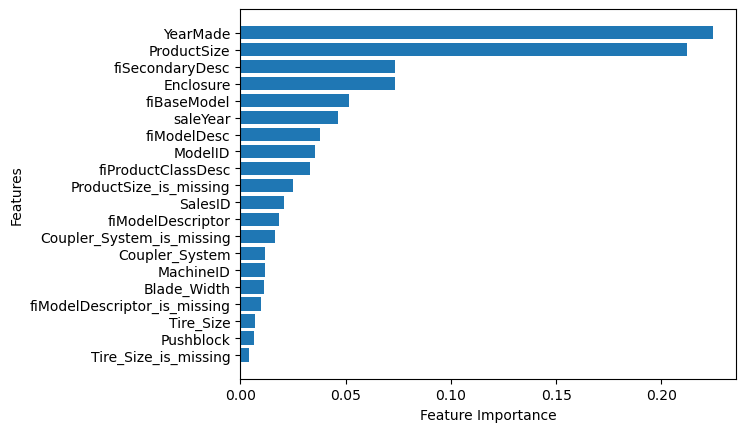

In [198]:
plot_features(x_train.columns,ideal_model.feature_importances_)

In [199]:
df["Enclosure"].value_counts()

Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64